# Backtesting Trading Strategies

## Objective

Classification metrics such as accuracy and precision do not necessarily translate into profitable trading strategies.

The purpose of this notebook is to simulate how our machine learning models would perform in a real trading environment.

We compare:

- Logistic Regression.
- Random Forest.
- XGBoost.
- A simple buy-and-hold strategy.

---

## Metrics

We evaluate:

- Cumulative returns.
- Sharpe ratio.
- Maximum drawdown.
- Final portfolio value.

---

## Trading rule

If the model predicts:

- 1 → Buy / Hold.
- 0 → Stay in cash.

For simplicity:

- No leverage.
- No transaction costs.
- One-day holding period.

In [1]:
# imports
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt

In [2]:
# Load dataset and models
df = pd.read_csv(
    "../data/btc_model_data.csv",
    parse_dates=["Date"]
)

logistic_model = joblib.load(
    "../models/logistic_regression.pkl"
)

rf_model = joblib.load(
    "../models/random_forest.pkl"
)

xgb_model = joblib.load(
    "../models/xgboost.pkl"
)

scaler = joblib.load(
    "../models/scaler.pkl"
)

In [3]:
# features
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Change",
    "Return",
    "Volume_Change",
    "Momentum_5",
    "MA_10",
    "MA_50",
    "Volatility",
    "RSI",
    "MACD",
    "MACD_Signal",
    "MACD_Hist"
]

In [4]:
# split
X = df[features]

y = df["Target"]

split = int(len(df) * 0.8)

X_test = X[split:]

test_df = df.iloc[split:].copy()

In [5]:
# predictions
X_test_scaled = scaler.transform(
    X_test
)

test_df["Logistic_Pred"] = logistic_model.predict(
    X_test_scaled
)

test_df["RF_Pred"] = rf_model.predict(
    X_test
)

test_df["XGB_Pred"] = xgb_model.predict(
    X_test
)

In [6]:
test_df[
    [
        "Date",
        "Close",
        "Target",
        "Logistic_Pred",
        "RF_Pred",
        "XGB_Pred"
    ]
].head()

,Date,Close,Target,Logistic_Pred,RF_Pred,XGB_Pred
967,2024-01-17,180.635315,1,1,0,0
968,2024-01-18,186.518707,1,0,0,0
969,2024-01-19,189.415924,1,0,0,1
970,2024-01-22,191.719849,1,0,0,0
971,2024-01-23,192.995407,0,0,0,0


# Market Returns

To simulate trading performance, we first compute the daily percentage return of Apple stock.

In [7]:
test_df["Market_Return"] = (
    test_df["Close"]
    .pct_change()
)

In [ ]:
# Simulate strategies
test_df["Logistic_Return"] = (
    test_df["Logistic_Pred"]
    * test_df["Market_Return"]
)

test_df["RF_Return"] = (
    test_df["RF_Pred"]
    * test_df["Market_Return"]
)

test_df["XGB_Return"] = (
    test_df["XGB_Pred"]
    * test_df["Market_Return"]
)

# Cumulative Returns

Daily returns alone do not show long-term performance.

We compound returns over time to estimate portfolio growth.

In [9]:
test_df["Buy_Hold"] = (
    1 + test_df["Market_Return"]
).cumprod()

test_df["Logistic_Cumulative"] = (
    1 + test_df["Logistic_Return"]
).cumprod()

test_df["RF_Cumulative"] = (
    1 + test_df["RF_Return"]
).cumprod()

test_df["XGB_Cumulative"] = (
    1 + test_df["XGB_Return"]
).cumprod()

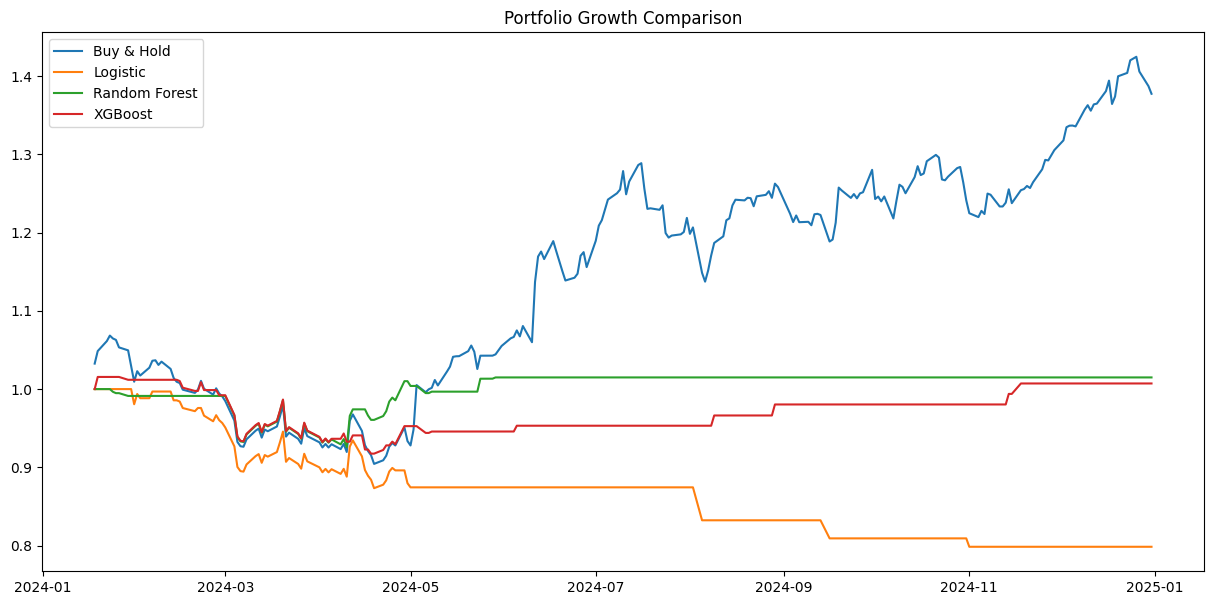

In [10]:
plt.figure(figsize=(15, 7))

plt.plot(
    test_df["Date"],
    test_df["Buy_Hold"],
    label="Buy & Hold"
)

plt.plot(
    test_df["Date"],
    test_df["Logistic_Cumulative"],
    label="Logistic"
)

plt.plot(
    test_df["Date"],
    test_df["RF_Cumulative"],
    label="Random Forest"
)

plt.plot(
    test_df["Date"],
    test_df["XGB_Cumulative"],
    label="XGBoost"
)

plt.legend()

plt.title(
    "Portfolio Growth Comparison"
)

plt.show()

# Sharpe Ratio

Sharpe ratio measures return per unit of risk.

Higher values indicate better risk-adjusted performance.

In [11]:
def sharpe_ratio(returns):

    return (
        returns.mean()
        /
        returns.std()
    ) * np.sqrt(252)

In [12]:
print(
    "Logistic:",
    sharpe_ratio(
        test_df["Logistic_Return"]
    )
)

print(
    "RF:",
    sharpe_ratio(
        test_df["RF_Return"]
    )
)

print(
    "XGB:",
    sharpe_ratio(
        test_df["XGB_Return"]
    )
)

Logistic: -1.9402927060179866
RF: 0.21034315914058388
XGB: 0.12788913195736185


# Maximum Drawdown

Maximum drawdown measures the worst portfolio decline from a peak.

Lower drawdowns indicate lower downside risk.

In [13]:
def max_drawdown(cumulative):

    peak = cumulative.cummax()

    drawdown = (
        cumulative - peak
    ) / peak

    return drawdown.min()

In [14]:
print(
    "RF Drawdown:",
    max_drawdown(
        test_df["RF_Cumulative"]
    )
)

RF Drawdown: -0.07428898318282817


# Key Findings

## 1. Machine learning models underperformed the market

All machine learning strategies failed to outperform a passive buy-and-hold strategy.

---

## 2. Accuracy does not imply profitability

Although Random Forest achieved the highest accuracy (43%), its portfolio growth remained close to zero.

---

## 3. Low recall limited performance

The models predicted upward movements too conservatively, causing them to miss most of the market rally.

---

## 4. Feature engineering is the bottleneck

Traditional technical indicators alone do not appear sufficient to predict short-term Apple price movements.

Additional information sources such as news sentiment, earnings data, and macroeconomic indicators may be necessary.